<div style="background-color:#00843D;padding:22px 28px;border-radius:12px;margin-bottom:4px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 01: La Neurona como Sistema Dinamico
## Del oscilador de Van der Pol al modelo de FitzHugh-Nagumo

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Simular** el modelo de FitzHugh-Nagumo aplicando el RK4 visto en clase
2. **Construir e interpretar** un diagrama de fase de un sistema autonomo de EDOs
3. **Identificar** el oscilador de Van der Pol como caso particular de FitzHugh-Nagumo
4. **Articular** el reto computacional que motiva el desarrollo de las Neural ODEs
5. **Conectar** la dinamica neuronal con el origen historico de las redes artificiales

### Prerequisitos

- Sistemas de EDOs de primer orden
- Metodo de Runge-Kutta de orden 4 (RK4) -- ya visto en clase
- Python basico y NumPy

---

> **Como leer este notebook:**
> - Las celdas marcadas con **[OK]** estan listas: presiona `Shift+Enter`
> - Las celdas marcadas con **[Ejercicio]** son para completar antes de continuar


## 1. Por que empezamos con una neurona biologica?

Puede parecer extrano que en **Analisis Numerico** empecemos hablando de neuronas.
La razon es sencilla: las **redes neuronales artificiales** estan inspiradas en el
cerebro biologico, y la neurona biologica es ante todo un **sistema dinamico no lineal**.

Para entender que simplificaciones se hicieron al crear las redes artificiales,
necesitamos ver primero *que* se estaba simplificando.

---

### El potencial de accion: la senal de una neurona

Cuando una neurona se activa, su voltaje interno sigue una trayectoria caracteristica:

```
voltaje (mV)
  +40 ----------
               |  despolarizacion
  -65 ---------   ------------------  <- potencial de reposo
                   |  hiperpolarizacion
                   --------------------
             |<-- ~2 ms -->|
```

Esta senal -- el **potencial de accion** o *spike* -- es la unidad basica de
informacion del sistema nervioso. El reto matematico: como modelarla con
ecuaciones a la vez precisas y computacionalmente manejables?


In [ ]:
# [OK] Ejecuta esta celda primero -- carga todas las librerias del notebook

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.0,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
})

VERDE   = "#00843D"
AZUL    = "#1a5fa8"
ROJO    = "#c0392b"
NARANJA = "#e67e22"
MORADO  = "#8e44ad"

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


## 2. Linea de tiempo: de la neurona biologica al Deep Learning

Antes de escribir una sola ecuacion, situemonos historicamente.
Los hitos marcados con (*) son los que cubriremos en este notebook.


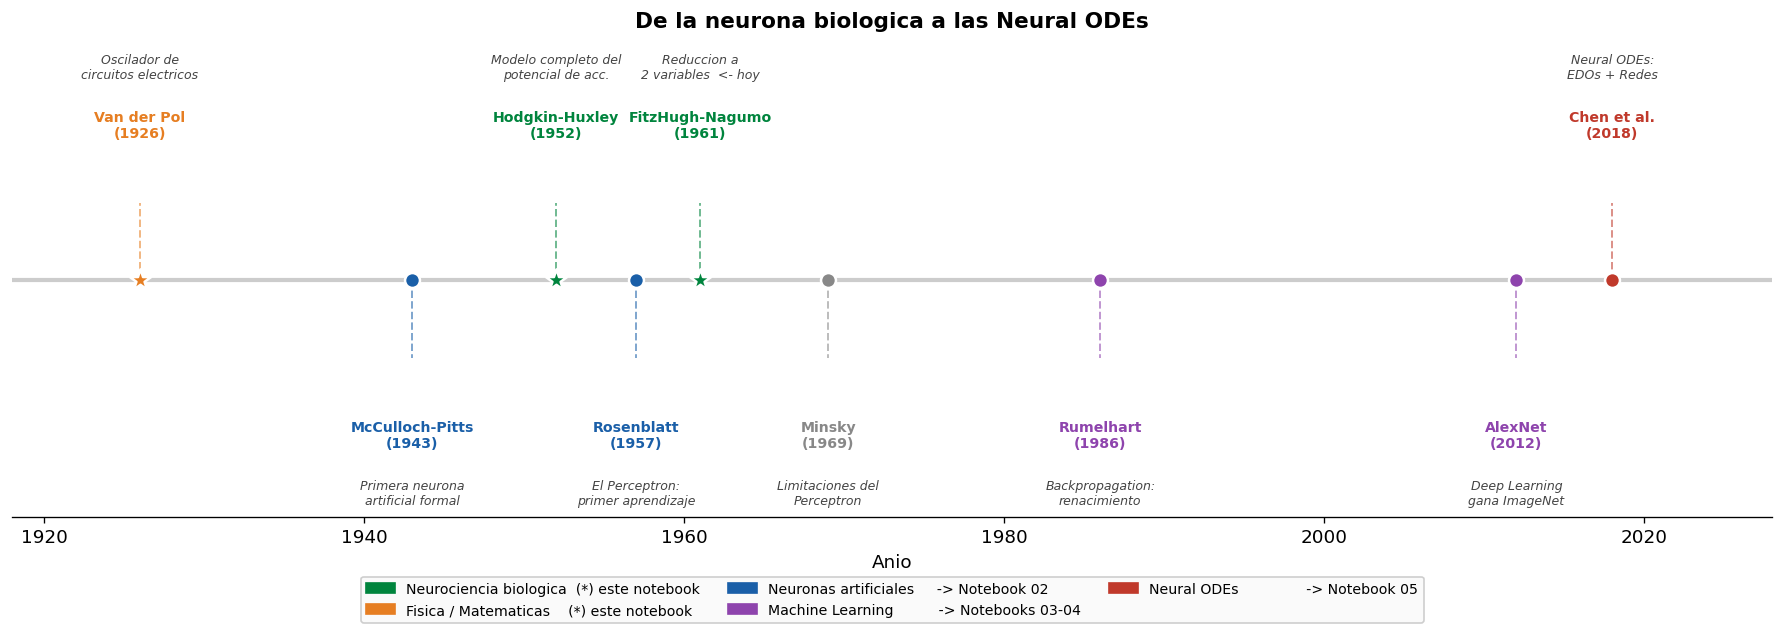

(*) = hitos de este notebook | Los demas se cubren en los siguientes notebooks


In [ ]:
# [OK] Linea de tiempo historica

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.set_facecolor("white")
ax.grid(False)
ax.set_xlim(1918, 2028)
ax.set_ylim(-3.2, 3.2)
ax.axhline(0, color="#cccccc", linewidth=2.5, zorder=1)

hitos = [
    (1926, +2.1, "Van der Pol\n(1926)",       "Oscilador de\ncircuitos electricos",    NARANJA, True),
    (1943, -2.1, "McCulloch-Pitts\n(1943)",   "Primera neurona\nartificial formal",     AZUL,    False),
    (1952, +2.1, "Hodgkin-Huxley\n(1952)",    "Modelo completo del\npotencial de acc.", VERDE,   True),
    (1957, -2.1, "Rosenblatt\n(1957)",        "El Perceptron:\nprimer aprendizaje",     AZUL,    False),
    (1961, +2.1, "FitzHugh-Nagumo\n(1961)",   "Reduccion a\n2 variables  <- hoy",       VERDE,   True),
    (1969, -2.1, "Minsky\n(1969)",            "Limitaciones del\nPerceptron",            "#888",  False),
    (1986, -2.1, "Rumelhart\n(1986)",         "Backpropagation:\nrenacimiento",           MORADO,  False),
    (2012, -2.1, "AlexNet\n(2012)",           "Deep Learning\ngana ImageNet",             MORADO,  False),
    (2018, +2.1, "Chen et al.\n(2018)",       "Neural ODEs:\nEDOs + Redes",               ROJO,    False),
]

for anio, y, titulo, desc, color, hoy in hitos:
    mk = "*" if hoy else "o"
    sz = 180 if hoy else 80
    ax.scatter(anio, 0, s=sz, color=color, zorder=6,
               marker=mk, edgecolors="white", linewidths=1.5)
    ax.plot([anio, anio], [0, y*0.5], color=color,
            linewidth=1.2, linestyle="--", alpha=0.55, zorder=2)
    ax.text(anio, y,      titulo, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color=color)
    ay = y + (0.78 if y > 0 else -0.78)
    ax.text(anio, ay,    desc,   ha="center", va="center",
            fontsize=7.5, color="#444", style="italic")

leyenda = [
    mpatches.Patch(color=VERDE,   label="Neurociencia biologica  (*) este notebook"),
    mpatches.Patch(color=NARANJA, label="Fisica / Matematicas    (*) este notebook"),
    mpatches.Patch(color=AZUL,    label="Neuronas artificiales     -> Notebook 02"),
    mpatches.Patch(color=MORADO,  label="Machine Learning          -> Notebooks 03-04"),
    mpatches.Patch(color=ROJO,    label="Neural ODEs               -> Notebook 05"),
]
ax.legend(handles=leyenda, loc="lower center", ncol=3, fontsize=8.5,
          framealpha=0.95, bbox_to_anchor=(0.5, -0.24))
ax.set_xlabel("Anio", fontsize=11)
ax.set_title("De la neurona biologica a las Neural ODEs", fontsize=13,
             fontweight="bold", pad=10)
ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
ax.spines["bottom"].set_visible(True)
plt.tight_layout()
plt.show()
print("(*) = hitos de este notebook | Los demas se cubren en los siguientes notebooks")


## 3. Hodgkin-Huxley (1952): el modelo completo

En 1952, Alan Hodgkin y Andrew Huxley publicaron el modelo matematico del potencial de
accion en el axon gigante del calamar. **Premio Nobel de Fisiologia, 1963.**
El modelo tiene **cuatro variables** acopladas:

$$\frac{dV}{dt} = \frac{1}{C_m}\!\left[I_{ext} - \bar{g}_{Na}\,m^3h\,(V-E_{Na}) - \bar{g}_K\,n^4\,(V-E_K) - \bar{g}_L(V-E_L)\right]$$

$$\frac{dm}{dt} = \alpha_m(V)(1-m) - \beta_m(V)\,m \qquad \frac{dh}{dt} = \alpha_h(V)(1-h) - \beta_h(V)\,h \qquad \frac{dn}{dt} = \alpha_n(V)(1-n) - \beta_n(V)\,n$$

Donde $m, h, n$ son variables de compuerta que controlan los canales ionicos.
**Extraordinariamente preciso, pero costoso de simular a escala.**

### La reduccion de FitzHugh (1961)

Las cuatro variables de HH se agrupan en dos escalas de tiempo:

| Grupo | Variables | Escala | Rol |
|-------|-----------|--------|-----|
| **Rapida** | $V$, $m$ | ~1 ms | Despolarizacion (el "disparo") |
| **Lenta** | $h$, $n$ | ~10 ms | Repolarizacion (la "recuperacion") |

Reduciendo a **una variable rapida** $v$ y **una lenta** $w$: solo **2 EDOs**.


## 4. El modelo de FitzHugh-Nagumo

$$\boxed{\frac{dv}{dt} = v - \frac{v^3}{3} - w + I_{ext}}$$

$$\boxed{\frac{dw}{dt} = \frac{1}{\tau}\left(v + a - b\,w\right)}$$

| Simbolo | Nombre | Rol | Escala |
|---------|--------|-----|--------|
| $v$ | Voltaje normalizado | Potencial de membrana | Rapida |
| $w$ | Recuperacion | Inactivacion de canales | Lenta ($\tau \gg 1$) |

| Parametro | Valor | Significado |
|-----------|-------|-------------|
| $a$ | 0.7 | Umbral de recuperacion |
| $b$ | 0.8 | Sensibilidad de $w$ a $v$ |
| $\tau$ | 12.5 | Separacion de escalas -- $w$ es ~12x mas lento |
| $I_{ext}$ | 0.5 | Corriente externa (el estimulo) |

> **Clave:** el termino $v^3/3$ en la ecuacion de $v$ genera la no linealidad esencial.
> Sin el, el sistema seria lineal y no habria potencial de accion.
> La cubica introduce una **inestabilidad controlada**: la neurona se "dispara"
> cuando el estimulo supera un umbral.


In [ ]:
# [Ejercicio 1] Implementar la ecuacion de recuperacion dw/dt

# Parametros del modelo
a     = 0.7    # Umbral de recuperacion
b     = 0.8    # Sensibilidad de la recuperacion
tau   = 12.5   # Separacion de escalas de tiempo
I_ext = 0.5    # Corriente externa


def fitzhugh_nagumo(estado, t, a, b, tau, I_ext):
    # estado = [v, w], t = tiempo actual
    # Retorna [dv_dt, dw_dt]
    v, w = estado

    # Ecuacion de voltaje -- DADA
    dv_dt = v - (v**3) / 3.0 - w + I_ext


    # ================================================
    # [Ejercicio] Completa la ecuacion de recuperacion.
    # Mira las ecuaciones en la celda anterior.
    # Usa: v, w, a, b, tau
    # ================================================
    dw_dt = (v+a-b*w)/tau   # <- reemplaza None con la expresion correcta

    return [dv_dt, dw_dt]


# Verificacion automatica
test = fitzhugh_nagumo([0.0, 0.0], 0, a, b, tau, I_ext)
print("Prueba en (v=0, w=0):")
print(f"  dv/dt = {test[0]:.4f}   (esperado:  0.5000)")
print(f"  dw/dt = {test[1]}")

if test[1] is None:
    print("\n[!] dw/dt es None -- completa el ejercicio antes de continuar.")
elif abs(test[1] - 0.056) < 0.002:
    print(f"\n[OK] Correcto!  dw/dt = {test[1]:.4f}  (esperado: ~0.0560)")
else:
    print(f"\n[!] Revisa: dw/dt = {test[1]:.4f}, el valor esperado es ~0.0560")

Prueba en (v=0, w=0):
  dv/dt = 0.5000   (esperado:  0.5000)
  dw/dt = 0.055999999999999994

[OK] Correcto!  dw/dt = 0.0560  (esperado: ~0.0560)


## 5. Recordemos: Runge-Kutta de orden 4

Para un sistema $\mathbf{y}^{\prime} = f(\mathbf{y},\,t)$ con paso $h$:

$$k_1 = f(\mathbf{y}_n,\; t_n)$$

$$k_2 = f\!\left(\mathbf{y}_n + \tfrac{h}{2}k_1,\; t_n+\tfrac{h}{2}\right)$$

$$k_3 = f\!\left(\mathbf{y}_n + \tfrac{h}{2}k_2,\; t_n+\tfrac{h}{2}\right)$$

$$k_4 = f\!\left(\mathbf{y}_n + h\,k_3,\; t_n+h\right)$$

$$\mathbf{y}_{n+1} = \mathbf{y}_n + \frac{h}{6}\!\left(k_1 + 2k_2 + 2k_3 + k_4\right)$$

Cuatro evaluaciones de $f$ por paso implican error local $O(h^5)$ y error global $O(h^4)$.

> **Conexion futura:** en el Notebook 05 veremos que la arquitectura ResNet es exactamente
> un paso de Euler ($k_1$ solamente), y RK-Net usa los cuatro puntos de RK4.
> Las Neural ODEs van un paso mas alla: reemplazan el integrador fijo por un
> **solver adaptativo** que elige el paso segun la dificultad local.


In [ ]:
# [Ejercicio 2] Completar el metodo RK4

def rk4_paso(f, y, t, h, **params):
    # Un paso de RK4.
    # f: funcion del sistema f(y, t, **params)
    # y: estado actual (array)
    # t: tiempo actual
    # h: tamano del paso
    y  = np.array(y, dtype=float)
    k1 = np.array(f(y, t, **params))

    # ================================================
    # [Ejercicio] Completa k2, k3 y k4.
    # Cada ki es un array con la misma forma que k1.
    # Usa las formulas de la celda anterior.
    # ================================================
    k2 = np.array(f(y+0.5*h*k1, t+h/2, **params))   # <- f en y + h/2*k1, tiempo t + h/2
    k3 = np.array(f(y+0.5*h*k2, t+h/2, **params))   # <- f en y + h/2*k2, tiempo t + h/2
    k4 = np.array(f(y+h*k3, t+h, **params))   # <- f en y + h*k3,   tiempo t + h

    y_next = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return y_next


def resolver_sistema(f, y0, t_span, h, **params):
    # Integra el sistema con RK4.
    # Retorna t (1D) e Y (2D: shape [n_pasos, n_vars])
    t0, tf = t_span
    t  = np.arange(t0, tf, h)
    Y  = np.zeros((len(t), len(y0)))
    Y[0] = y0
    for i in range(1, len(t)):
        Y[i] = rk4_paso(f, Y[i-1], t[i-1], h, **params)
    return t, Y


# Prueba de integridad
params_fn = dict(a=a, b=b, tau=tau, I_ext=I_ext)
try:
    t_p, Y_p = resolver_sistema(fitzhugh_nagumo, [-1.0, -0.5], (0, 5), 0.01, **params_fn)
    print(f"[OK] RK4 funciona. Estado en t=5:  v={Y_p[-1,0]:.4f},  w={Y_p[-1,1]:.4f}")
    print("     Procede a la siguiente celda para la simulacion completa.")
except TypeError as e:
    print("[!] Error -- probablemente k2, k3 o k4 siguen siendo None.")
    print(f"    Detalle: {e}")

[OK] RK4 funciona. Estado en t=5:  v=1.9229,  w=0.1160
     Procede a la siguiente celda para la simulacion completa.


In [ ]:
# [OK] Simulacion completa del sistema FitzHugh-Nagumo

t, Y = resolver_sistema(
    fitzhugh_nagumo,
    y0     = [-1.0, -0.5],   # Condicion inicial (v0, w0)
    t_span = (0, 200),        # 200 unidades de tiempo
    h      = 0.01,
    **params_fn
)

print(f"Simulacion completada: {len(t):,} pasos,  t_final = {t[-1]:.0f}")

Simulacion completada: 20,000 pasos,  t_final = 200


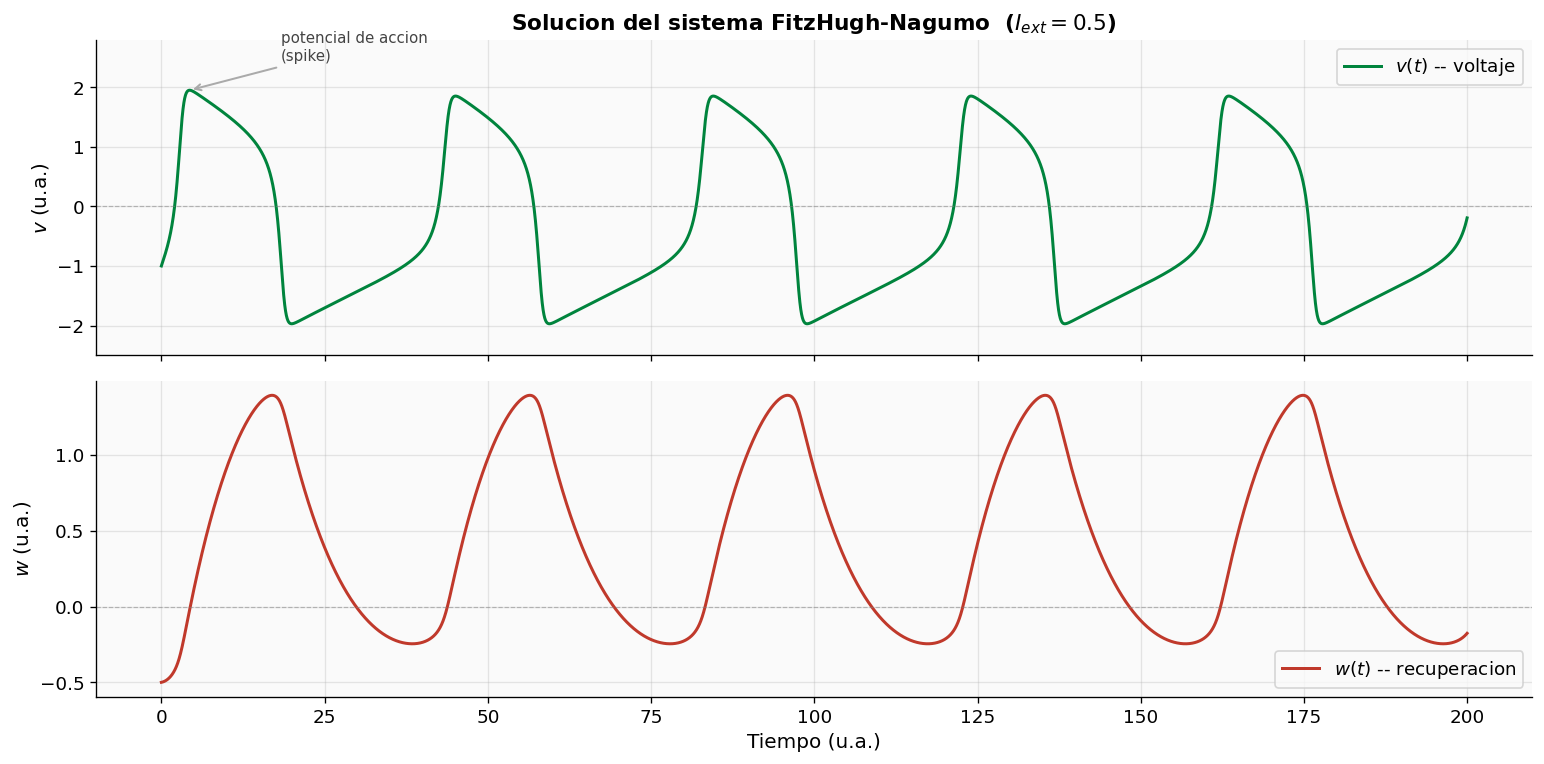

Observa:
  v(t) sube bruscamente -> periodo refractario -> reposo -> siguiente disparo
  w(t) oscila con retardo -- es la variable lenta (tau=12.5 veces mas lento)
  Los disparos son periodicos: la neurona esta en el regimen de ciclo limite


In [ ]:
# [OK] Visualizacion de v(t) y w(t): el potencial de accion simulado

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)

axes[0].plot(t, Y[:, 0], color=VERDE, linewidth=1.8, label=r"$v(t)$ -- voltaje")
axes[0].axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
axes[0].set_ylabel(r"$v$ (u.a.)", fontsize=12)
axes[0].set_title(r"Solucion del sistema FitzHugh-Nagumo  ($I_{ext}=0.5$)",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].set_ylim(-2.5, 2.8)

idx_pico = np.argmax(Y[50:700, 0]) + 50
axes[0].annotate("potencial de accion\n(spike)", fontsize=9, color="#444",
                 xy=(t[idx_pico], Y[idx_pico, 0]),
                 xytext=(t[idx_pico] + 14, Y[idx_pico, 0] + 0.5),
                 arrowprops=dict(arrowstyle="->", color="#aaa", lw=1.2))

axes[1].plot(t, Y[:, 1], color=ROJO, linewidth=1.8, label=r"$w(t)$ -- recuperacion")
axes[1].axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
axes[1].set_ylabel(r"$w$ (u.a.)", fontsize=12)
axes[1].set_xlabel("Tiempo (u.a.)", fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Observa:")
print("  v(t) sube bruscamente -> periodo refractario -> reposo -> siguiente disparo")
print("  w(t) oscila con retardo -- es la variable lenta (tau=12.5 veces mas lento)")
print("  Los disparos son periodicos: la neurona esta en el regimen de ciclo limite")


## 6. Diagrama de fase: ver todas las trayectorias a la vez

Hasta ahora graficamos $v(t)$ y $w(t)$ para una condicion inicial.
El **diagrama de fase** muestra la evolucion en el **plano** $(v,\,w)$ para
cualquier condicion inicial simultaneamente.

| Elemento | Significado |
|----------|-------------|
| Un **punto** $(v, w)$ | Estado del sistema en algun instante |
| Las **flechas** (campo vectorial) | Direccion de evolucion desde ese estado |
| Una **curva cerrada** | **Ciclo limite** -- oscilacion permanente (disparo repetido) |
| Un **punto fijo** estable | Equilibrio -- la neurona en reposo |

### Las nulclinas: fronteras del espacio de fases

Las **nulclinas** son las curvas donde una derivada se anula:

$$\frac{dv}{dt} = 0 \;\Rightarrow\; w = v - \frac{v^3}{3} + I_{ext} \qquad \text{(nulclina de }v\text{, cubica)}$$

$$\frac{dw}{dt} = 0 \;\Rightarrow\; w = \frac{v + a}{b} \qquad \text{(nulclina de }w\text{, lineal)}$$

Su **interseccion** es el **punto de equilibrio** del sistema.
En cada region del plano, las nulclinas indican si $v$ y $w$ crecen o decrecen.


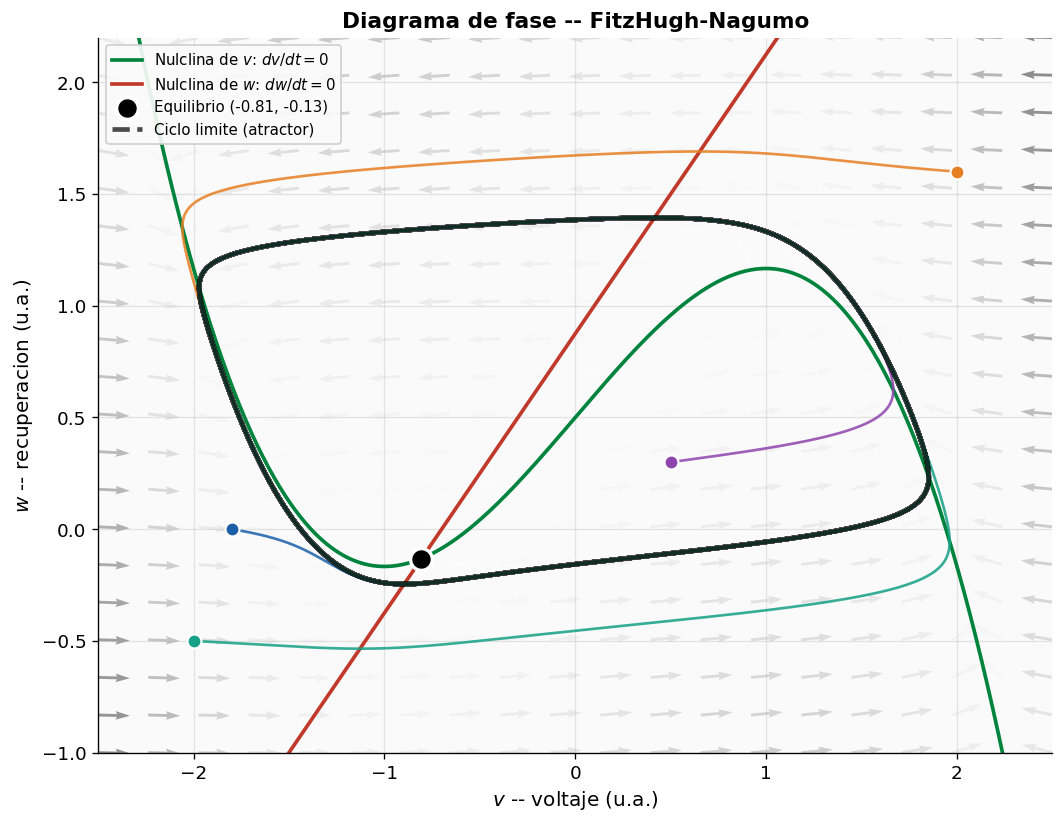

Todas las trayectorias (de colores) convergen al ciclo limite (negro --)
El ciclo limite es el ATRACTOR: disparo repetido es el estado estacionario
Las nulclinas dividen el plano en regiones con dinamica diferente


In [ ]:
# [OK] Diagrama de fase: campo vectorial, nulclinas y trayectorias

fig, ax = plt.subplots(figsize=(9, 7))

# Campo de vectores
v_g = np.linspace(-2.5, 2.5, 20)
w_g = np.linspace(-1.0, 2.2, 20)
Vg, Wg = np.meshgrid(v_g, w_g)
dV = Vg - (Vg**3)/3 - Wg + I_ext
dW = (Vg + a - b*Wg) / tau
nr = np.sqrt(dV**2 + dW**2); nr[nr == 0] = 1
ax.quiver(Vg, Wg, dV/nr, dW/nr, nr, cmap="Greys",
          alpha=0.45, scale=30, width=0.003)

# Nulclinas
v_nl = np.linspace(-2.5, 2.5, 500)
nulv = v_nl - (v_nl**3)/3 + I_ext
nulw = (v_nl + a) / b
ax.plot(v_nl, nulv, color=VERDE, linewidth=2.2, label=r"Nulclina de $v$: $dv/dt=0$")
ax.plot(v_nl, nulw, color=ROJO,  linewidth=2.2, label=r"Nulclina de $w$: $dw/dt=0$")

# Punto de equilibrio
idx_eq = np.argmin(np.abs(nulv - nulw))
v_eq, w_eq = v_nl[idx_eq], nulv[idx_eq]
ax.scatter(v_eq, w_eq, s=170, color="black", zorder=10,
           edgecolors="white", linewidths=2,
           label=f"Equilibrio ({v_eq:.2f}, {w_eq:.2f})")

# Trayectorias desde 4 condiciones iniciales
cis = [([-1.8, 0.0], AZUL), ([0.5, 0.3], MORADO),
       ([2.0, 1.6], NARANJA), ([-2.0, -0.5], "#16a085")]
for ci, color in cis:
    _, Ytraj = resolver_sistema(fitzhugh_nagumo, ci, (0, 120), 0.01, **params_fn)
    ax.plot(Ytraj[:, 0], Ytraj[:, 1], color=color, linewidth=1.6, alpha=0.85)
    ax.scatter(ci[0], ci[1], s=70, color=color, zorder=8,
               edgecolors="white", linewidths=1.3)

# Ciclo limite (atractor)
_, Y_long = resolver_sistema(fitzhugh_nagumo, [-1.0, -0.5], (0, 600), 0.01, **params_fn)
ax.plot(Y_long[4000:, 0], Y_long[4000:, 1],
        color="black", linewidth=2.8, linestyle="--",
        alpha=0.7, label="Ciclo limite (atractor)", zorder=5)

ax.set_xlabel(r"$v$ -- voltaje (u.a.)", fontsize=12)
ax.set_ylabel(r"$w$ -- recuperacion (u.a.)", fontsize=12)
ax.set_title("Diagrama de fase -- FitzHugh-Nagumo", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left", framealpha=0.92)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.0, 2.2)
plt.tight_layout()
plt.show()

print("Todas las trayectorias (de colores) convergen al ciclo limite (negro --)")
print("El ciclo limite es el ATRACTOR: disparo repetido es el estado estacionario")
print("Las nulclinas dividen el plano en regiones con dinamica diferente")


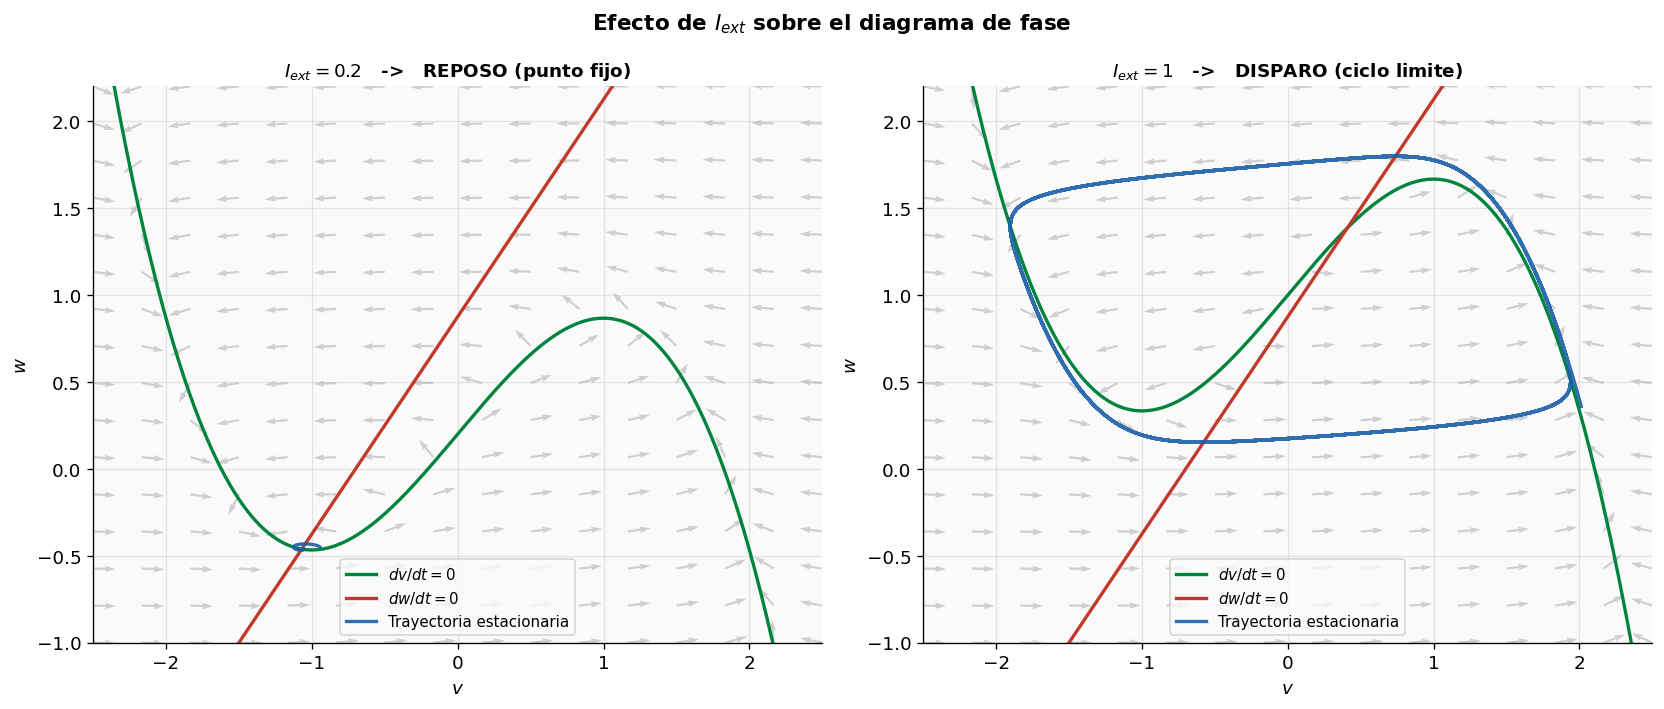

Entre que valores de I_ext ocurre la bifurcacion reposo -> disparo?


In [ ]:
# [Ejercicio 3] Explorar el efecto de la corriente externa I_ext
#
# Modifica I_explorar y observa como cambia el comportamiento.
# Prueba: 0.0 (reposo), 0.3 (umbral?), 0.5 (ya visto), 1.0 (mas rapido?)
#
# Pregunta: existe un valor umbral de I_ext donde la neurona
# pasa de reposo a disparo? Puedes encontrarlo aproximadamente?

I_explorar = 1   # <- CAMBIA ESTE VALOR

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, I_val in enumerate([0.2, I_explorar]):
    ax = axes[ax_idx]
    p  = dict(a=a, b=b, tau=tau, I_ext=I_val)

    v_nl = np.linspace(-2.5, 2.5, 500)
    nulv_i = v_nl - (v_nl**3)/3 + I_val
    nulw_i = (v_nl + a) / b

    ax.plot(v_nl, nulv_i, color=VERDE, linewidth=2, label=r"$dv/dt=0$")
    ax.plot(v_nl, nulw_i, color=ROJO,  linewidth=2, label=r"$dw/dt=0$")

    vg2 = np.linspace(-2.5, 2.5, 16)
    wg2 = np.linspace(-1.0, 2.2, 16)
    Vg2, Wg2 = np.meshgrid(vg2, wg2)
    dV2 = Vg2 - (Vg2**3)/3 - Wg2 + I_val
    dW2 = (Vg2 + a - b*Wg2) / tau
    nr2 = np.sqrt(dV2**2 + dW2**2); nr2[nr2==0] = 1
    ax.quiver(Vg2, Wg2, dV2/nr2, dW2/nr2, alpha=0.35, scale=32,
              width=0.003, color="gray")

    _, Ytraj2 = resolver_sistema(fitzhugh_nagumo, [-1.0, -0.5], (0, 350), 0.01, **p)
    ax.plot(Ytraj2[500:, 0], Ytraj2[500:, 1],
            color=AZUL, linewidth=2, alpha=0.9, label="Trayectoria estacionaria")

    amp = np.max(Ytraj2[2000:, 0]) - np.min(Ytraj2[2000:, 0])
    regimen = "DISPARO (ciclo limite)" if amp > 1.5 else "REPOSO (punto fijo)"
    ax.set_title(f"$I_{{ext}} = {I_val}$   ->   {regimen}", fontsize=11, fontweight="bold")
    ax.set_xlabel(r"$v$", fontsize=11)
    ax.set_ylabel(r"$w$", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.0, 2.2)

plt.suptitle(r"Efecto de $I_{ext}$ sobre el diagrama de fase",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Entre que valores de I_ext ocurre la bifurcacion reposo -> disparo?")


## 7. El oscilador de Van der Pol: el antepasado fisico

Balthasar van der Pol (1926) estudiaba **circuitos electricos con tubos de vacio**
(los transistores de su epoca). Encontro que ciertos circuitos oscilaban de forma
estable y lo modelo con:

$$\frac{dx}{dt} = \mu\!\left(x - \frac{x^3}{3} - y\right) \qquad \frac{dy}{dt} = \frac{x}{\mu}$$

Compara con FitzHugh-Nagumo:

| FitzHugh-Nagumo | Van der Pol | Rol |
|----------------|------------|-----|
| $v$ | $x$ | Variable rapida |
| $w$ | $y$ | Variable lenta |
| $1/\tau$ | $1/\mu^2$ | Separacion de escalas |

**Van der Pol es un caso particular de FN** con $a=0$, $b=0$, $I_{ext}=0$.

El parametro $\mu$ controla la rigidez del oscilador:
- $\mu \ll 1$ -> oscilacion casi sinusoidal (suave)
- $\mu \gg 1$ -> oscilacion tipo "relax" (rigida o *stiff*: cambia rapido, luego lento)

> **Reflexion importante:** el mismo modelo matematico aparece en 1926 estudiando
> circuitos electricos y en 1961 estudiando neuronas. No es una coincidencia -- refleja que
> **la oscilacion es un fenomeno universal** en sistemas no lineales con retroalimentacion.


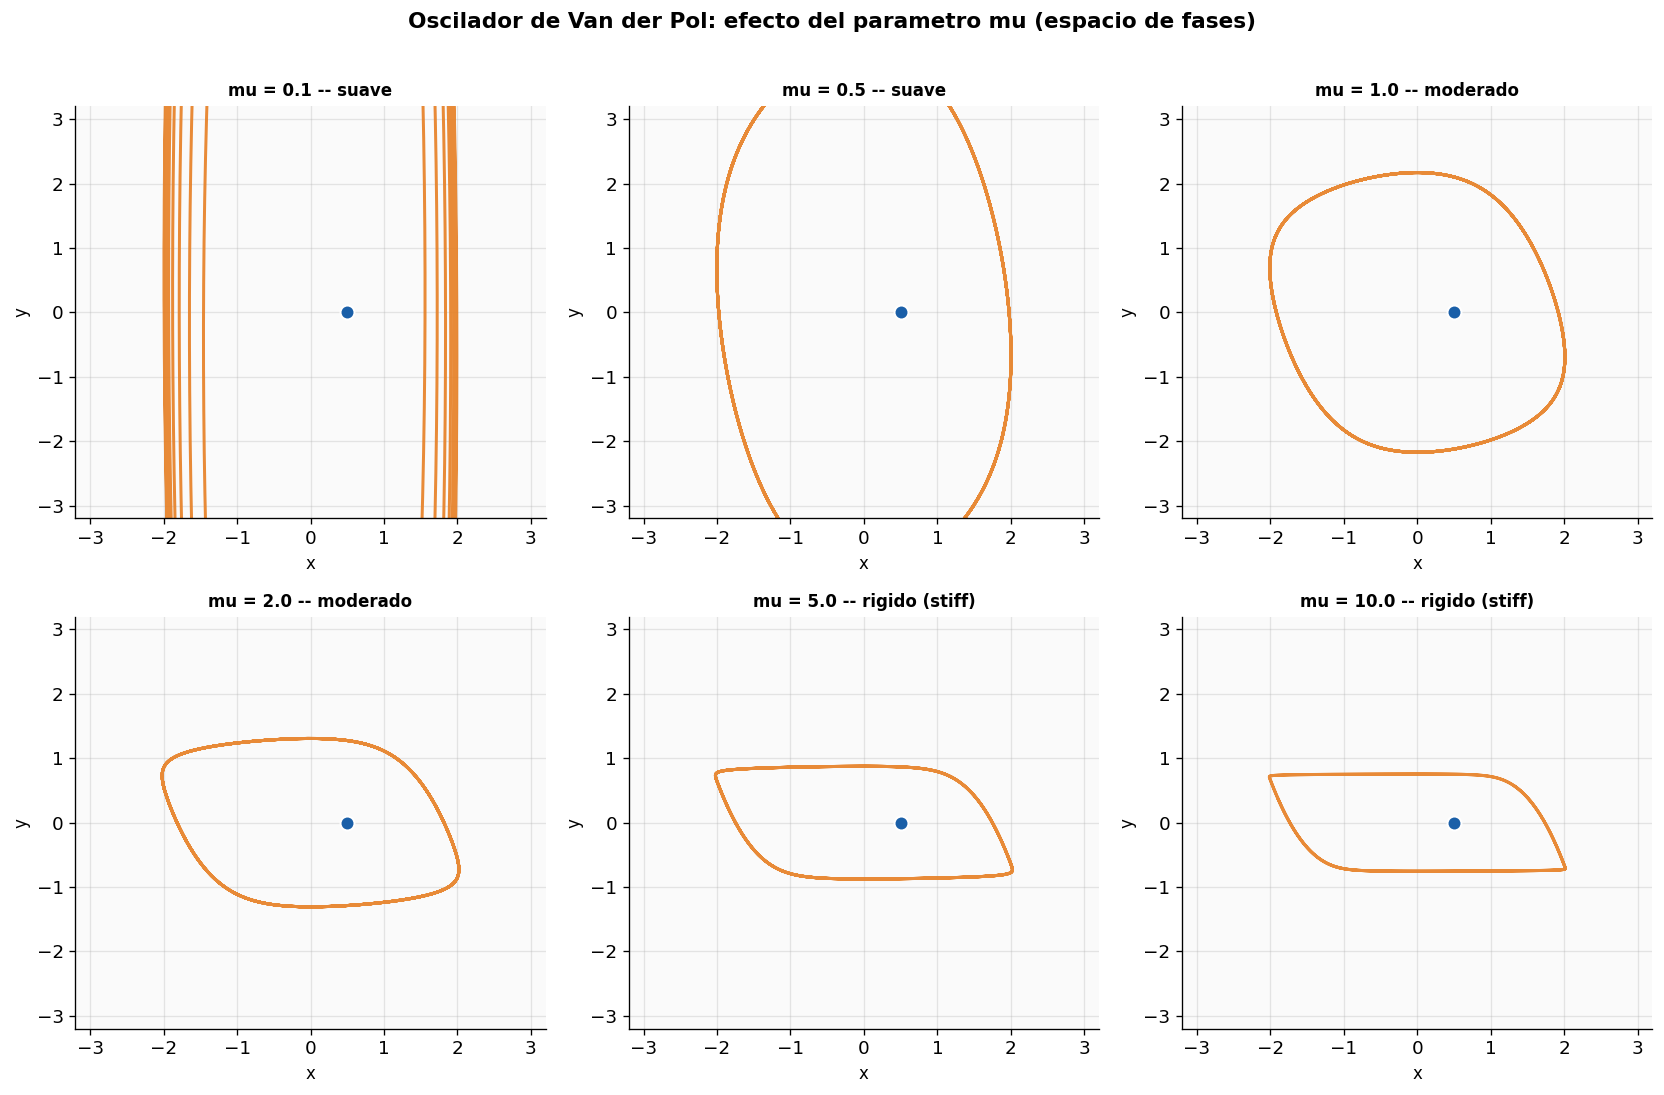

mu pequeno -> ciclo limite circular (cambios suaves)
mu grande  -> ciclo limite con esquinas abruptas (stiff)

STIFFNESS motiva los solvers adaptativos -> Neural ODEs (Notebook 05)


In [ ]:
# [OK + Ejercicio 4] Oscilador de Van der Pol

def van_der_pol(estado, t, mu):
    x, y = estado
    return [mu*(x - (x**3)/3.0 - y),  x/mu]


fig, axes = plt.subplots(2, 3, figsize=(14, 9))
mu_vals = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

for ax, mu in zip(axes.flat, mu_vals):
    t_vdp, Y_vdp = resolver_sistema(
        van_der_pol, [0.5, 0.0], (0, 80), 0.005, mu=mu)
    corte = len(t_vdp) // 3
    ax.plot(Y_vdp[corte:, 0], Y_vdp[corte:, 1],
            color=NARANJA, linewidth=1.8, alpha=0.9)
    ax.scatter(0.5, 0.0, s=70, color=AZUL, zorder=5,
               edgecolors="white", linewidths=1.2)
    tipo = "suave" if mu < 1 else ("moderado" if mu < 3 else "rigido (stiff)")
    ax.set_title(f"mu = {mu} -- {tipo}", fontsize=10, fontweight="bold")
    ax.set_xlabel("x", fontsize=10); ax.set_ylabel("y", fontsize=10)
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)

plt.suptitle("Oscilador de Van der Pol: efecto del parametro mu (espacio de fases)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ================================================
# [Ejercicio 4] Para mu=10 el sistema es STIFF.
# Prueba cambiar h de 0.005 a 0.1 para mu=10:
#
#   t_s, Y_s = resolver_sistema(van_der_pol, [0.5, 0.0],
#                               (0, 80), 0.1, mu=10.0)
#   plt.plot(Y_s[:, 0], Y_s[:, 1])
#   plt.title("Van der Pol mu=10, h=0.1")
#   plt.show()
#
# Que observas? Por que RK4 falla con h grande en sistemas stiff?
# ================================================

print("mu pequeno -> ciclo limite circular (cambios suaves)")
print("mu grande  -> ciclo limite con esquinas abruptas (stiff)")
print("")
print("STIFFNESS motiva los solvers adaptativos -> Neural ODEs (Notebook 05)")


## 8. El reto actual: escala y complejidad

Ahora que entendemos la dinamica de **una sola neurona**, contemplemos la escala real:

- Cerebro humano: **~86 000 millones** de neuronas
- Cada neurona: **~7 000** conexiones sinapticas
- Modelo de Hodgkin-Huxley: **4 EDOs por neurona**

Simular el cerebro humano con fidelidad biologica requeriria integrar del orden de
$10^{12}$ ecuaciones diferenciales acopladas simultaneamente.

Con hardware actual, **eso tomaria millones de anos de computo**.


/tmp/ipykernel_5365/612100858.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


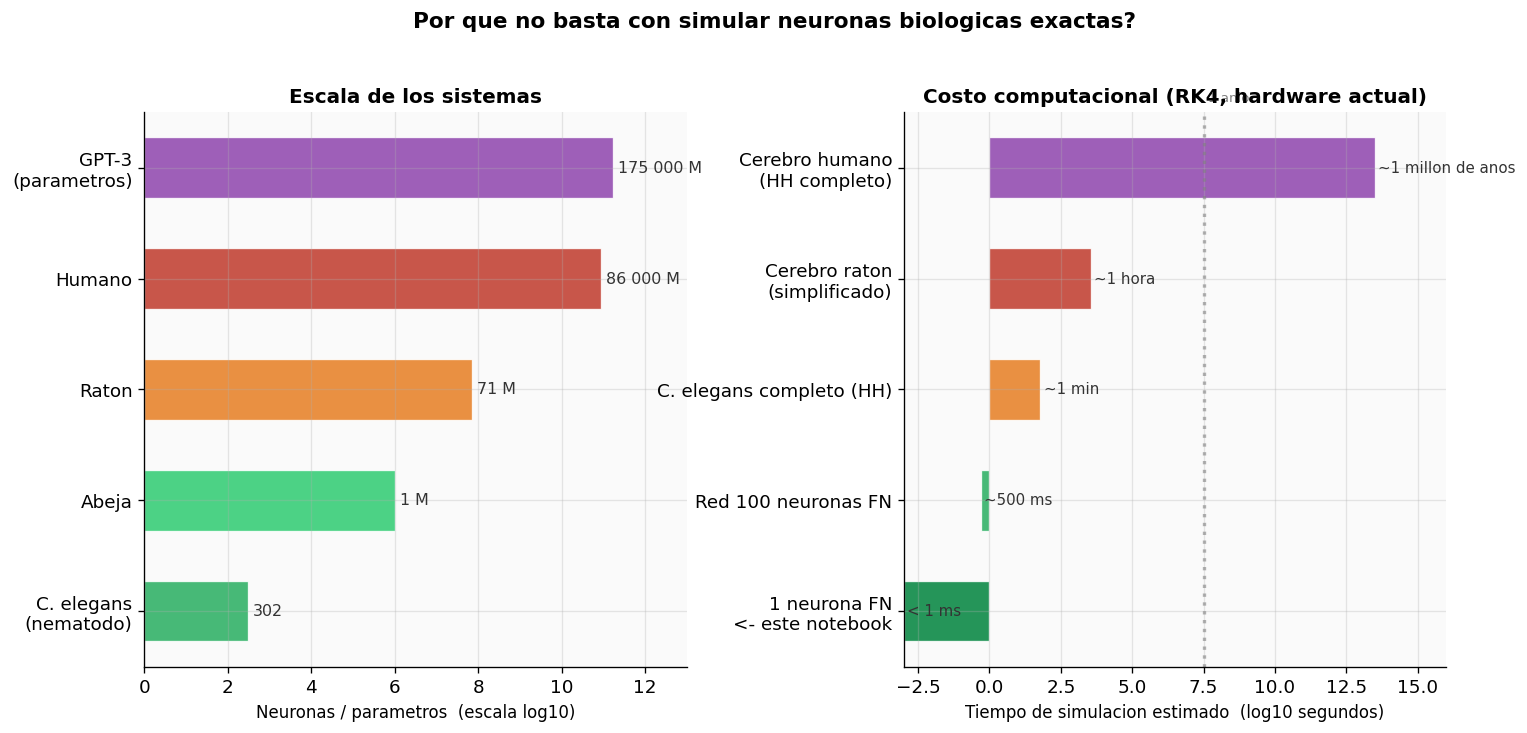

La solucion historica:
  McCulloch & Pitts (1943): abstraer la neurona a su funcion computacional minima.
  Sin EDOs, sin dinamica temporal -- solo algebra lineal + un umbral.
  -> Notebook 02: El Perceptron


In [ ]:
# [OK] El reto computacional en perspectiva

fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, wspace=0.4)

# Panel izq: escala
ax1 = fig.add_subplot(gs[0, 0])
sistemas = [
    ("C. elegans\n(nematodo)",   302,                "#27ae60"),
    ("Abeja",                     1_000_000,           "#2ecc71"),
    ("Raton",                     71_000_000,          NARANJA),
    ("Humano",                    86_000_000_000,      ROJO),
    ("GPT-3\n(parametros)",      175_000_000_000,     MORADO),
]
labels_s = [s[0] for s in sistemas]
logs_s   = [np.log10(s[1]) for s in sistemas]
cols_s   = [s[2] for s in sistemas]
bars1 = ax1.barh(labels_s, logs_s, color=cols_s, alpha=0.85, height=0.55,
                 edgecolor="white", linewidth=0.8)
etiq_s = ["302", "1 M", "71 M", "86 000 M", "175 000 M"]
for bar, etq in zip(bars1, etiq_s):
    ax1.text(bar.get_width()+0.12, bar.get_y()+bar.get_height()/2,
             etq, va="center", fontsize=9.5, color="#333")
ax1.set_xlabel("Neuronas / parametros  (escala log10)", fontsize=10)
ax1.set_title("Escala de los sistemas", fontsize=12, fontweight="bold")
ax1.set_xlim(0, 13)

# Panel der: costo de simulacion
ax2 = fig.add_subplot(gs[0, 1])
sims = [
    ("1 neurona FN\n<- este notebook",   0.001,    VERDE),
    ("Red 100 neuronas FN",                0.5,      "#27ae60"),
    ("C. elegans completo (HH)",           60,       NARANJA),
    ("Cerebro raton\n(simplificado)",     3_600,    ROJO),
    ("Cerebro humano\n(HH completo)",     3.15e13,  MORADO),
]
labels_t = [s[0] for s in sims]
logs_t   = [np.log10(s[1]) for s in sims]
cols_t   = [s[2] for s in sims]
bars2 = ax2.barh(labels_t, logs_t, color=cols_t, alpha=0.85, height=0.55,
                 edgecolor="white", linewidth=0.8)
etiq_t = ["< 1 ms", "~500 ms", "~1 min", "~1 hora", "~1 millon de anos"]
for bar, etq in zip(bars2, etiq_t):
    ax2.text(bar.get_width()+0.12, bar.get_y()+bar.get_height()/2,
             etq, va="center", fontsize=9, color="#333")
ax2.set_xlabel("Tiempo de simulacion estimado  (log10 segundos)", fontsize=10)
ax2.set_title("Costo computacional (RK4, hardware actual)", fontsize=12, fontweight="bold")
ax2.set_xlim(-3, 16)
ax2.axvline(np.log10(3.15e7), color="gray", linestyle=":", alpha=0.6)
ax2.text(np.log10(3.15e7)+0.15, 4.6, "1 anio", fontsize=8, color="gray")

plt.suptitle("Por que no basta con simular neuronas biologicas exactas?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("La solucion historica:")
print("  McCulloch & Pitts (1943): abstraer la neurona a su funcion computacional minima.")
print("  Sin EDOs, sin dinamica temporal -- solo algebra lineal + un umbral.")
print("  -> Notebook 02: El Perceptron")


## 9. Puente: de la neurona biologica a la artificial

McCulloch y Pitts propusieron en 1943 que una neurona realiza tres operaciones:

1. **Recibe** senales de otras neuronas: $x_1, x_2, \ldots, x_n$
2. **Pondera** cada senal segun la fuerza de la conexion: $w_1, w_2, \ldots, w_n$
3. **Se activa** si la suma ponderada supera un umbral $\theta$:

$$\text{salida} = \begin{cases} 1 & \text{si} \quad \displaystyle\sum_{i} w_i x_i > \theta \\\ 0 & \text{en caso contrario} \end{cases}$$

Esto elimina por completo la dinamica temporal del FitzHugh-Nagumo.
**No hay EDOs. No hay RK4. No hay ciclos limite.** Solo algebra lineal y un umbral.

---

### Resumen del Notebook 01

| Concepto | Lo que aprendimos |
|----------|------------------|
| **Hodgkin-Huxley** | Modelo completo (4 EDOs) -- preciso pero computacionalmente costoso |
| **FitzHugh-Nagumo** | Reduccion a 2 EDOs -- captura la esencia del disparo neuronal |
| **RK4** | Integrador de alta precision para sistemas no lineales autonomos |
| **Diagrama de fase** | Visualiza todas las trayectorias; revela atractores y equilibrios |
| **Nulclinas** | Curvas donde $dv/dt=0$ o $dw/dt=0$ -- analisis cualitativo sin resolver |
| **Van der Pol** | Caso particular de FN -- misma matematica, contexto historico diferente |
| **El reto** | Simular redes neuronales biologicas exactas es computacionalmente inviable |

---

### Siguiente: Notebook 02 -- El Perceptron

Implementaremos desde cero la neurona artificial de McCulloch-Pitts y el Perceptron
de Rosenblatt (1957) -- la primera red que **aprende de datos** ajustando sus pesos.

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
